In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

In [10]:
data=sns.load_dataset('titanic',usecols=['survived','age','fare','class','deck'])
data=data.iloc[:,[0,1,2]]
data.head()

,survived,age,fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [13]:
data.isna().sum()

survived    0
age         0
fare        0
dtype: int64

In [12]:
data['age'].fillna(data['age'].mean(),inplace=True)

In [14]:
from sklearn.model_selection import train_test_split,cross_val_score

In [16]:
X_train,X_test,y_train,y_test=train_test_split(data.drop(columns=['survived']),data['survived'],test_size=0.2,random_state=42)
X_train.shape,X_test.shape

((712, 2), (179, 2))

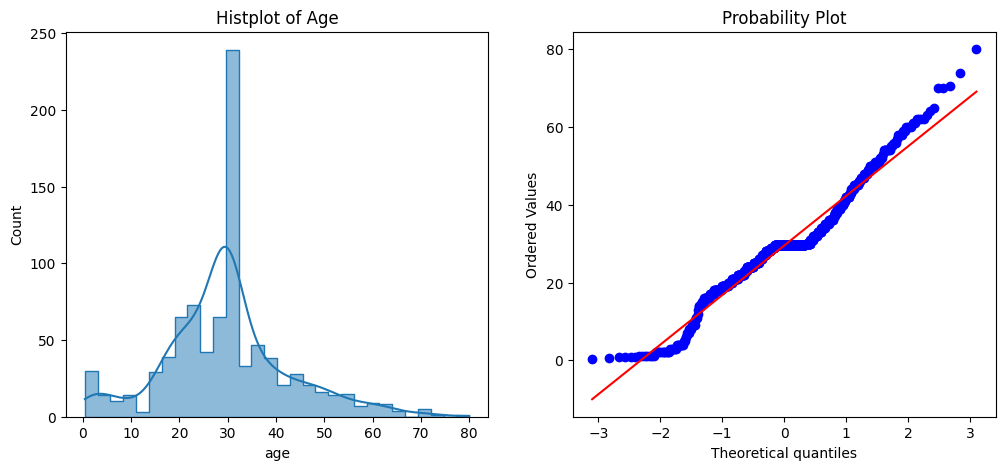

In [27]:
from scipy import stats
import matplotlib.pyplot as plt

fig=plt.figure(figsize=(12,5))
ax1=fig.add_subplot(121)
sns.histplot(x=data['age'],element='step',kde=True)
ax1.set_title('Histplot of Age')

ax2=fig.add_subplot(122)
stats.probplot(x=X_train['age'],dist='norm',plot=ax2)
plt.show()

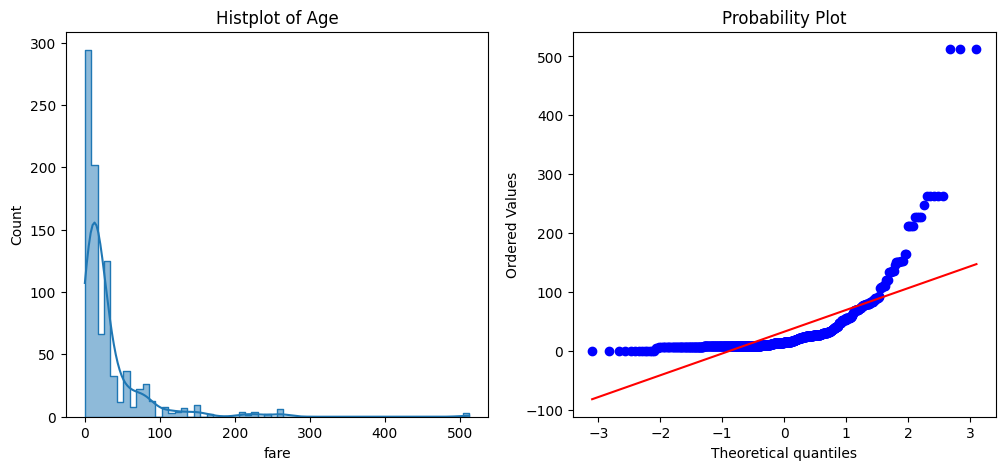

In [28]:

fig=plt.figure(figsize=(12,5))
ax1=fig.add_subplot(121)
sns.histplot(x=data['fare'],element='step',kde=True)
ax1.set_title('Histplot of Age')

ax2=fig.add_subplot(122)
stats.probplot(x=X_train['fare'],dist='norm',plot=ax2)
plt.show()

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [30]:
from sklearn.metrics import accuracy_score

clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)
    
y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.6871508379888268


In [31]:
from sklearn.preprocessing import FunctionTransformer

In [32]:
trf = FunctionTransformer(func=np.log1p)

In [33]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [34]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)
    
y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6759776536312849


In [37]:
X=data.drop(columns=['survived'])
y=data['survived']

X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6689513108614233


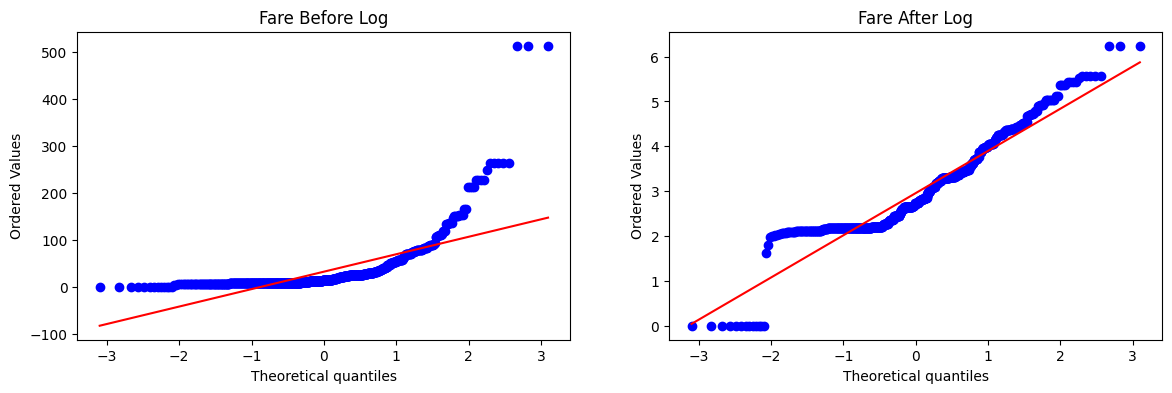

In [39]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()

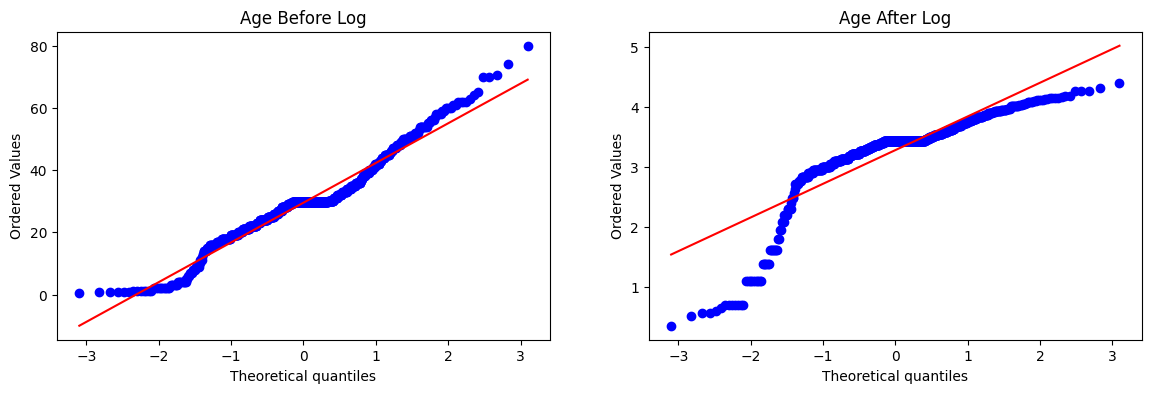

In [40]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['age'], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

In [43]:
from sklearn.compose import ColumnTransformer
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [44]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)
    
y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.664804469273743


In [45]:
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6554556803995006


In [50]:
def apply_transform(transform):
    X = data.iloc[:,1:3]
    y = data.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()
    

Accuracy 0.6712609238451936


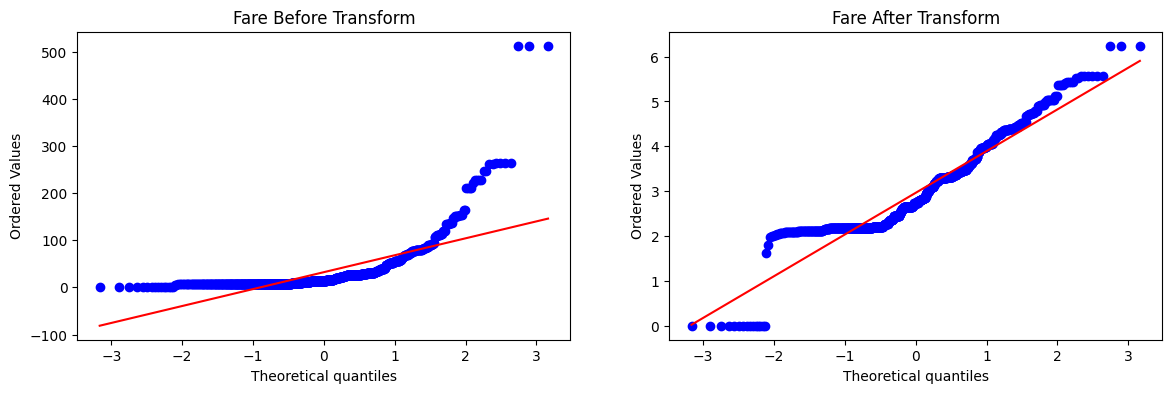

In [54]:
apply_transform(np.log1p)